# Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

---

# 1. Load Dataset

In [4]:
pd.set_option("display.max_columns", None)

df = pd.read_csv("Sport_car_price.csv")
df.head(10)

,Car Make,Car Model,Year,Engine Size (L),Horsepower,Torque (lb-ft),0-60 MPH Time (seconds),Price (in USD)
0,Porsche,911,2022,3,379,331,4,"101,200"
1,Lamborghini,Huracan,2021,5.2,630,443,2.8,"274,390"
2,Ferrari,488 GTB,2022,3.9,661,561,3,"333,750"
3,Audi,R8,2022,5.2,562,406,3.2,"142,700"
4,McLaren,720S,2021,4,710,568,2.7,"298,000"
5,BMW,M8,2022,4.4,617,553,3.1,"130,000"
6,Mercedes-Benz,AMG GT,2021,4,523,494,3.8,"118,500"
7,Chevrolet,Corvette,2021,6.2,490,465,2.8,"59,900"
8,Ford,Mustang Shelby GT500,2022,5.2,760,625,3.5,"81,000"
9,Nissan,GT-R Nismo,2021,3.8,600,481,2.5,"212,000"


In [5]:

cols_to_fix = ['Horsepower', 'Torque (lb-ft)', '0-60 MPH Time (seconds)', 'Price (in USD)', 'Engine Size (L)']

for col in cols_to_fix:
    
    df[col] = pd.to_numeric(df[col].astype(str).str.replace(r'[$,+]', '', regex=True).str.replace(',', ''), errors='coerce')


numeric_c = df.select_dtypes(include=np.number).columns
print("Updated numeric columns:", numeric_c.tolist())

Updated numeric columns: ['Year', 'Engine Size (L)', 'Horsepower', 'Torque (lb-ft)', '0-60 MPH Time (seconds)', 'Price (in USD)']


## 2. Data Quality Assessment
### 2.1 Check Data Types

In [6]:
df.dtypes

Car Make                       str
Car Model                      str
Year                         int64
Engine Size (L)            float64
Horsepower                   int64
Torque (lb-ft)             float64
0-60 MPH Time (seconds)    float64
Price (in USD)               int64
dtype: object

In [7]:
df.shape

(1007, 8)

### 2.2 Convert Incorrect Data Types

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1007 entries, 0 to 1006
Data columns (total 8 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Car Make                 1007 non-null   str    
 1   Car Model                1007 non-null   str    
 2   Year                     1007 non-null   int64  
 3   Engine Size (L)          948 non-null    float64
 4   Horsepower               1007 non-null   int64  
 5   Torque (lb-ft)           1003 non-null   float64
 6   0-60 MPH Time (seconds)  1006 non-null   float64
 7   Price (in USD)           1007 non-null   int64  
dtypes: float64(3), int64(3), str(2)
memory usage: 63.1 KB


In [9]:
df.describe()

,Year,Engine Size (L),Horsepower,Torque (lb-ft),0-60 MPH Time (seconds),Price (in USD)
count,1007.000000,948.000000,1007.000000,1003.000000,1006.000000,1.007000e+03
mean,2021.201589,4.395781,657.984111,559.570289,3.515010,3.820359e+05
std,2.019802,1.398801,593.017842,441.380051,0.776358,7.383227e+05
min,1965.000000,0.000000,181.000000,0.000000,1.800000,2.500000e+04
25%,2021.000000,3.500000,454.000000,406.000000,2.900000,7.180000e+04
50%,2021.000000,4.000000,591.000000,509.000000,3.500000,1.400000e+05
75%,2022.000000,5.200000,708.500000,604.000000,4.000000,2.500000e+05
max,2023.000000,8.400000,10000.000000,10000.000000,6.500000,5.200000e+06


In [10]:
df.isnull().sum()

Car Make                    0
Car Model                   0
Year                        0
Engine Size (L)            59
Horsepower                  0
Torque (lb-ft)              4
0-60 MPH Time (seconds)     1
Price (in USD)              0
dtype: int64

In [11]:
df.duplicated().sum()

np.int64(292)

# 3. Handling Missing Values

In [ ]:
numeric_c = df.select_dtypes(include=np.number).columns
df[numeric_c] = df[numeric_c].fillna(df[numeric_c].median())

,Year,Engine Size (L),Horsepower,Torque (lb-ft),0-60 MPH Time (seconds),Price (in USD)
0,2022,3.0,379,331.0,4.00,101200
1,2021,5.2,630,443.0,2.80,274390
2,2022,3.9,661,561.0,3.00,333750
3,2022,5.2,562,406.0,3.20,142700
4,2021,4.0,710,568.0,2.70,298000
...,...,...,...,...,...,...
1002,2022,5.0,1280,1106.0,2.50,3000000
1003,2021,4.0,1972,1254.0,2.00,2000000
1004,2021,4.0,789,590.0,2.70,1000000
1005,2021,6.0,764,738.0,3.00,2600000


In [13]:
print(f"Remainig missing values : {df.isnull().sum().sum() }")

Remainig missing values : 64


# 4. Handling Outliers

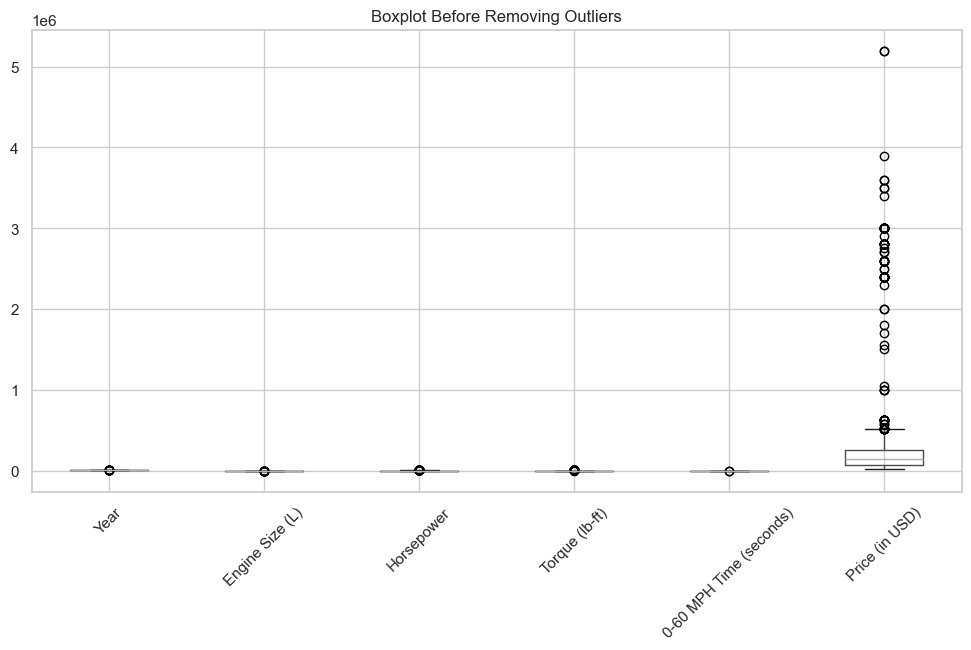

In [14]:
plt.figure(figsize=(12,6))
df[numeric_c].boxplot(rot=45)
plt.title("Boxplot Before Removing Outliers")
plt.show()

In [15]:

Q1 = df['Price (in USD)'].quantile(0.25)
Q3 = df['Price (in USD)'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR 

df_no_outliers = df[(df['Price (in USD)'] >= lower_bound) & (df['Price (in USD)'] <= upper_bound)].copy()

print(f"Original shape: {df.shape}")
print(f"Shape after removing price outliers: {df_no_outliers.shape}")

Original shape: (1007, 8)
Shape after removing price outliers: (889, 8)


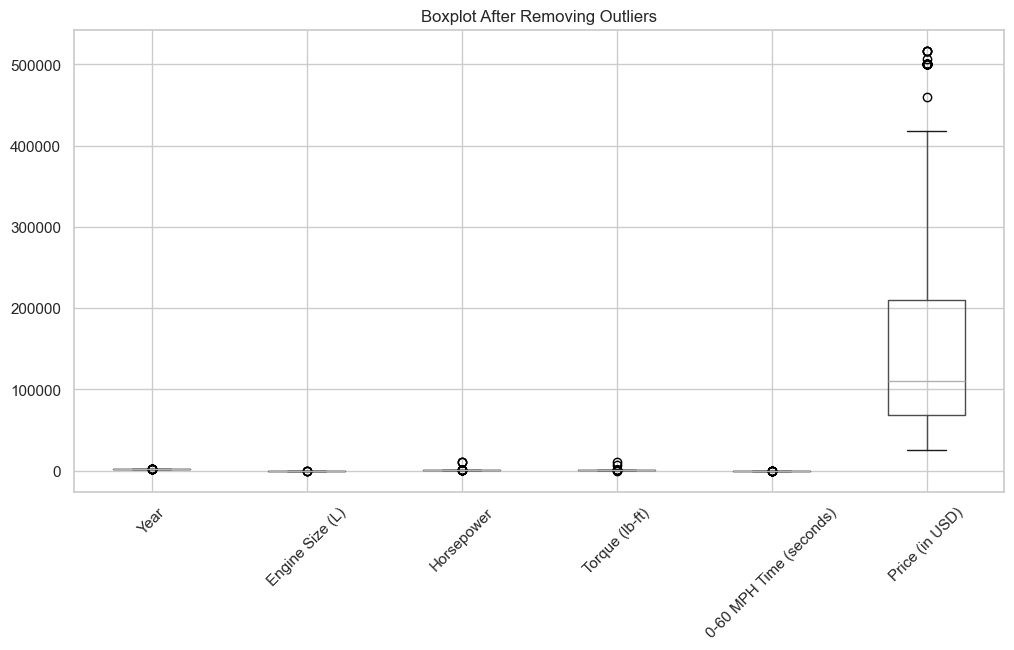

In [16]:
plt.figure(figsize=(12,6))
df_no_outliers[numeric_c].boxplot(rot=45)
plt.title("Boxplot After Removing Outliers")
plt.show()

# 5. Data Transformation - Normalization

In [74]:
pca_features = ['Horsepower', 'Torque (lb-ft)', '0-60 MPH Time (seconds)', 'Price (in USD)']
df_no_outliers = df_no_outliers.dropna(subset=pca_features)

print(f"Dataset is now 100% clean for PCA. Rows remaining: {len(df_no_outliers)}")

Dataset is now 100% clean for PCA. Rows remaining: 884


### Min-Max Scaling

In [ ]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.decomposition import PCA

pca_features = ['Horsepower', 'Torque (lb-ft)', '0-60 MPH Time (seconds)', 'Price (in USD)']
df_no_outliers = df_no_outliers.dropna(subset=pca_features)

data_to_scale = df_no_outliers[pca_features]


minmax_scaler = MinMaxScaler()
df_minmax = pd.DataFrame(minmax_scaler.fit_transform(data_to_scale), columns=pca_features)

print("Min-Max Normalized Data (First 5 rows):")
df_minmax.head()

NameError: name 'pca_features' is not defined

### Z-Score Normalization

In [ ]:
features_to_check = ['Horsepower', 'Torque (lb-ft)', '0-60 MPH Time (seconds)', 'Price (in USD)']
std_scaler = StandardScaler()
df_zscore_scaled = std_scaler.fit_transform(df_no_outliers[features_to_check])


df_zscore = pd.DataFrame(df_zscore_scaled, columns=features_to_check)

print("Z-Score Normalized Data (First 5 rows):")
df_zscore.head()

NameError: name 'pca_features' is not defined

# 6. Data Reduction - PCA

### Correlation before PCA

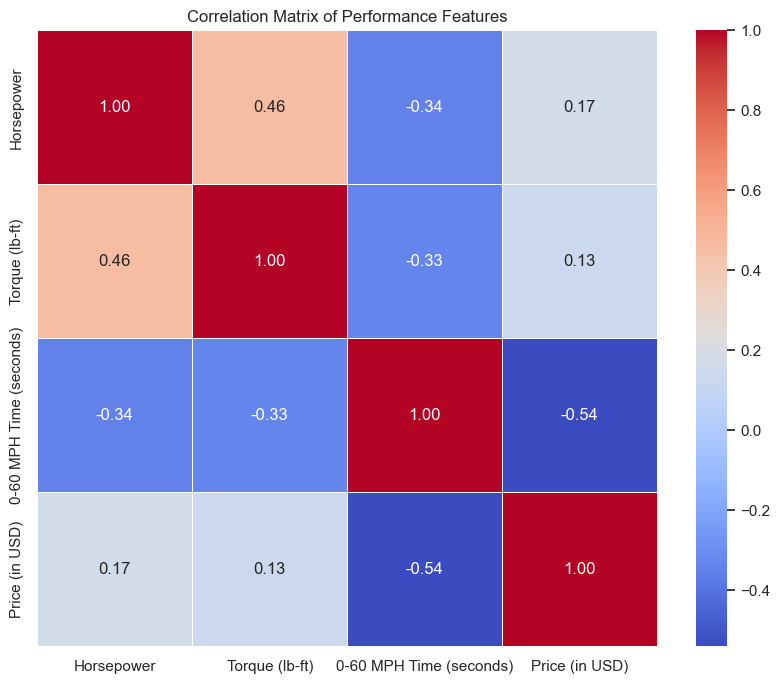

In [20]:
correlation_features = ['Horsepower', 'Torque (lb-ft)', '0-60 MPH Time (seconds)', 'Price (in USD)']
corr_matrix = df_no_outliers[correlation_features].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title("Correlation Matrix of Performance Features")
plt.show()

In [21]:
pca = PCA()
pca_results = pca.fit_transform(df_zscore_scaled)
explained_variance = pca.explained_variance_ratio_
print("Explained Variance Ratio by Each Principal Component:")
for i, ratio in enumerate(explained_variance):
    print(f"Principal Component {i+1}: ({ratio*100:.2f})%")

NameError: name 'df_zscore_scaled' is not defined

In [22]:
plt.figure(figsize=(8, 5))
plt.bar(range(1, len(explained_variance) + 1), explained_variance, alpha=0.7, label='Individual Variance')
plt.step(range(1, len(explained_variance) + 1), np.cumsum(explained_variance), where='mid', label='Cumulative Variance', color='red')

plt.title("PCA Explained Variance (Scree Plot)")
plt.xlabel("Principal Components")
plt.ylabel("Variance Explained Ratio")
plt.legend(loc='best')
plt.grid(axis='y', linestyle='--')
plt.show()

NameError: name 'explained_variance' is not defined

<Figure size 800x500 with 0 Axes>